# GABLS4 LES Intercomparison Study for Stable Boundary Layers: Sensitivity with respect to Spatial Resolution

In [1]:
from IPython.display import display, Markdown
from datetime import datetime, timezone
display(Markdown(f"*Last run: {datetime.now(timezone.utc).strftime('%B %d, %Y at %H:%M UTC')}*"))

*Last run: June 24, 2026 at 09:27 UTC*

For case setup and physical parameters, see the [Description](SBL_GABLS4_Description.ipynb) notebook.

Resolutions compared: $64^3$, $128^3$, $256^3$, $384^3$; SGS: LASDD-SM (SP). Profiles shown at 5 UTC (simulation hour 5) and 17 UTC (simulation hour 17). The simulation starts at 0 UTC; the Dome C site is at 75.1°S.

## Setup

The next cells load Python packages, locate the simulation outputs, and define the vertical grid and snapshot times.

In [13]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directories

In [14]:
from pathlib import Path

def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate jaxalfa repository root')

BaseDir = find_repo_root()

def read_config(run_dir):
    cfg = {}
    exec((run_dir / 'Config.py').read_text(), cfg)
    return cfg


optSGS = 1  # LASDD-SM: 1, LASDD-WL: 2, LAD-SM: 3, LAD-WL: 4

_sgs       = {1: 'LASDD_SM', 2: 'LASDD_WL', 3: 'LAD_SM', 4: 'LAD_WL'}
_sgs_label = {1: 'LASDD-SM', 2: 'LASDD-WL', 3: 'LAD-SM', 4: 'LAD-WL'}
sgs_str = _sgs[optSGS]

OutputDir1 = BaseDir / f'examples_A6000ada/SBL_GABLS4/runs/64x64x64_{sgs_str}_SP/output'
OutputDir2 = BaseDir / f'examples_A6000ada/SBL_GABLS4/runs/128x128x128_{sgs_str}_SP/output'
OutputDir3 = BaseDir / f'examples_A6000ada/SBL_GABLS4/runs/256x256x256_{sgs_str}_SP/output'
OutputDir4 = BaseDir / f'examples_A6000ada/SBL_GABLS4/runs/384x384x384_{sgs_str}_SP/output'

### Case configuration

In [15]:
cfg_1 = read_config(OutputDir1.parent)
cfg_2 = read_config(OutputDir2.parent)
cfg_3 = read_config(OutputDir3.parent)
cfg_4 = read_config(OutputDir4.parent)

nz_1 = int(cfg_1['nz'])
nz_2 = int(cfg_2['nz'])
nz_3 = int(cfg_3['nz'])
nz_4 = int(cfg_4['nz'])

l_z                = float(cfg_1['l_z'])
OutputInterval_sec = float(cfg_1['OutputInterval_sec'])
z_damping          = float(cfg_1.get('z_damping', 700.0))

print(f'Resolutions nz: {nz_1}, {nz_2}, {nz_3}, {nz_4}')
print(f'l_z={l_z:g} m, OutputInterval={OutputInterval_sec:g} s')
print(f'Damping layer above z={z_damping:g} m')

Resolutions nz: 64, 128, 256, 384
l_z=1000 m, OutputInterval=600 s
Damping layer above z=700 m


### Vertical grids and snapshot indices

In [16]:
# Half levels — U, V, TH, u2, v2, TH2
z_1 = np.array([(k + 0.5) * l_z / (nz_1 - 1) for k in range(nz_1)])
z_2 = np.array([(k + 0.5) * l_z / (nz_2 - 1) for k in range(nz_2)])
z_3 = np.array([(k + 0.5) * l_z / (nz_3 - 1) for k in range(nz_3)])
z_4 = np.array([(k + 0.5) * l_z / (nz_4 - 1) for k in range(nz_4)])

# Full (staggered) levels — w, uw, vw, wTH, txz, tyz, qz
z_w1 = np.array([k * l_z / (nz_1 - 1) for k in range(nz_1)])
z_w2 = np.array([k * l_z / (nz_2 - 1) for k in range(nz_2)])
z_w3 = np.array([k * l_z / (nz_3 - 1) for k in range(nz_3)])
z_w4 = np.array([k * l_z / (nz_4 - 1) for k in range(nz_4)])

# GABLS4 simulation starts at 0 UTC.
# 5 UTC  = simulation hour  5 h = 18 000 s
# 17 UTC = simulation hour 17 h = 61 200 s
T_snap1_s =  5.0 * 3600
T_snap2_s = 17.0 * 3600

snap1_index = int(T_snap1_s / OutputInterval_sec) - 1   # 29
snap2_index = int(T_snap2_s / OutputInterval_sec) - 1   # 101

print(f'5 UTC  (sim h  5): file index {snap1_index}')
print(f'17 UTC (sim h 17): file index {snap2_index}')

5 UTC  (sim h  5): file index 29
17 UTC (sim h 17): file index 101


### Snapshot loader

In [17]:
def LoadSnapshot(stat_files, snap_index, nz_expected):
    if len(stat_files) == 0 or snap_index >= len(stat_files):
        print(f'No data at index {snap_index}; plotting NaN placeholders for nz={nz_expected}.')
        nan = np.full(nz_expected, np.nan)
        return tuple(nan.copy() for _ in range(15))
    with np.load(stat_files[snap_index]) as d:
        return (
            d['U'].copy(),   d['V'].copy(),   d['TH'].copy(),
            d['u2'].copy(),  d['v2'].copy(),  d['w2'].copy(),
            d['TH2'].copy(),
            d['uv'].copy(),  d['uw'].copy(),  d['vw'].copy(),
            d['txy'].copy(), d['txz'].copy(), d['tyz'].copy(),
            d['wTH'].copy(), d['qz'].copy()
        )

### Available statistics files

In [18]:
def get_stat_files(output_dir):
    files = sorted(
        glob.glob(str(output_dir / 'ALFA_Statistics_Iteration_*.npz')),
        key=lambda x: int(re.search(r'Iteration_(\d+)', x).group(1))
    )
    return files

StatFiles1 = get_stat_files(OutputDir1)
StatFiles2 = get_stat_files(OutputDir2)
StatFiles3 = get_stat_files(OutputDir3)
StatFiles4 = get_stat_files(OutputDir4)

print(f'64^3  : {len(StatFiles1)} files')
print(f'128^3 : {len(StatFiles2)} files')
print(f'256^3 : {len(StatFiles3)} files')
print(f'384^3 : {len(StatFiles4)} files')

64^3  : 144 files
128^3 : 144 files
256^3 : 144 files
384^3 : 0 files


### Load snapshots

In [19]:
# ---- 5 UTC (simulation hour 5) ----
(U1_a, V1_a, TH1_a, u2_1a, v2_1a, w2_1a, TH2_1a,
 uv_1a, uw_1a, vw_1a, txy_1a, txz_1a, tyz_1a,
 wTH_1a, qz_1a) = LoadSnapshot(StatFiles1, snap1_index, nz_1)

(U2_a, V2_a, TH2_a, u2_2a, v2_2a, w2_2a, TH2_2a,
 uv_2a, uw_2a, vw_2a, txy_2a, txz_2a, tyz_2a,
 wTH_2a, qz_2a) = LoadSnapshot(StatFiles2, snap1_index, nz_2)

(U3_a, V3_a, TH3_a, u2_3a, v2_3a, w2_3a, TH2_3a,
 uv_3a, uw_3a, vw_3a, txy_3a, txz_3a, tyz_3a,
 wTH_3a, qz_3a) = LoadSnapshot(StatFiles3, snap1_index, nz_3)

(U4_a, V4_a, TH4_a, u2_4a, v2_4a, w2_4a, TH2_4a,
 uv_4a, uw_4a, vw_4a, txy_4a, txz_4a, tyz_4a,
 wTH_4a, qz_4a) = LoadSnapshot(StatFiles4, snap1_index, nz_4)

# ---- 17 UTC (simulation hour 17) ----
(U1_b, V1_b, TH1_b, u2_1b, v2_1b, w2_1b, TH2_1b,
 uv_1b, uw_1b, vw_1b, txy_1b, txz_1b, tyz_1b,
 wTH_1b, qz_1b) = LoadSnapshot(StatFiles1, snap2_index, nz_1)

(U2_b, V2_b, TH2_b, u2_2b, v2_2b, w2_2b, TH2_2b,
 uv_2b, uw_2b, vw_2b, txy_2b, txz_2b, tyz_2b,
 wTH_2b, qz_2b) = LoadSnapshot(StatFiles2, snap2_index, nz_2)

(U3_b, V3_b, TH3_b, u2_3b, v2_3b, w2_3b, TH2_3b,
 uv_3b, uw_3b, vw_3b, txy_3b, txz_3b, tyz_3b,
 wTH_3b, qz_3b) = LoadSnapshot(StatFiles3, snap2_index, nz_3)

(U4_b, V4_b, TH4_b, u2_4b, v2_4b, w2_4b, TH2_4b,
 uv_4b, uw_4b, vw_4b, txy_4b, txz_4b, tyz_4b,
 wTH_4b, qz_4b) = LoadSnapshot(StatFiles4, snap2_index, nz_4)

# ---- Derived quantities ----
S1_a = np.sqrt(U1_a**2 + V1_a**2);  S1_b = np.sqrt(U1_b**2 + V1_b**2)
S2_a = np.sqrt(U2_a**2 + V2_a**2);  S2_b = np.sqrt(U2_b**2 + V2_b**2)
S3_a = np.sqrt(U3_a**2 + V3_a**2);  S3_b = np.sqrt(U3_b**2 + V3_b**2)
S4_a = np.sqrt(U4_a**2 + V4_a**2);  S4_b = np.sqrt(U4_b**2 + V4_b**2)

uw_tot_1a = uw_1a + txz_1a;  uw_tot_1b = uw_1b + txz_1b
vw_tot_1a = vw_1a + tyz_1a;  vw_tot_1b = vw_1b + tyz_1b
wT_tot_1a = wTH_1a + qz_1a;  wT_tot_1b = wTH_1b + qz_1b

uw_tot_2a = uw_2a + txz_2a;  uw_tot_2b = uw_2b + txz_2b
vw_tot_2a = vw_2a + tyz_2a;  vw_tot_2b = vw_2b + tyz_2b
wT_tot_2a = wTH_2a + qz_2a;  wT_tot_2b = wTH_2b + qz_2b

uw_tot_3a = uw_3a + txz_3a;  uw_tot_3b = uw_3b + txz_3b
vw_tot_3a = vw_3a + tyz_3a;  vw_tot_3b = vw_3b + tyz_3b
wT_tot_3a = wTH_3a + qz_3a;  wT_tot_3b = wTH_3b + qz_3b

uw_tot_4a = uw_4a + txz_4a;  uw_tot_4b = uw_4b + txz_4b
vw_tot_4a = vw_4a + tyz_4a;  vw_tot_4b = vw_4b + tyz_4b
wT_tot_4a = wTH_4a + qz_4a;  wT_tot_4b = wTH_4b + qz_4b

print('Snapshots loaded.')

No data at index 29; plotting NaN placeholders for nz=384.
No data at index 101; plotting NaN placeholders for nz=384.
Snapshots loaded.


In [20]:
plt.rcParams.update({
    'text.usetex'    : True,
    'font.size'      : 14,
    'axes.labelsize' : 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

z_max = z_damping   # show only below the damping layer
z_max_a = 500.0     # 5 UTC profiles
z_max_b = 120.0     # 17 UTC profiles
z_maxs  = [z_max_a, z_max_b]

run_styles = {
    '64x64x64'  : {'color': 'red',   'linestyle': '-'},
    '128x128x128': {'color': 'blue',  'linestyle': '-'},
    '256x256x256': {'color': 'green', 'linestyle': '-'},
    '384x384x384': {'color': 'black', 'linestyle': '-'},
}

def prf(ax, x, z, xlabel, run_label):
    s = run_styles[run_label]
    ax.plot(x, z, color=s['color'], linestyle=s['linestyle'], linewidth=2, label=run_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$z$ (m)')
    ax.set_ylim(0, z_max)

## Mean Wind and Hodograph

Horizontal mean wind components ($U$, $V$), wind-speed magnitude, and hodograph at the two target times. Top row: 5 UTC (simulation hour 5); bottom row: 17 UTC (simulation hour 17).

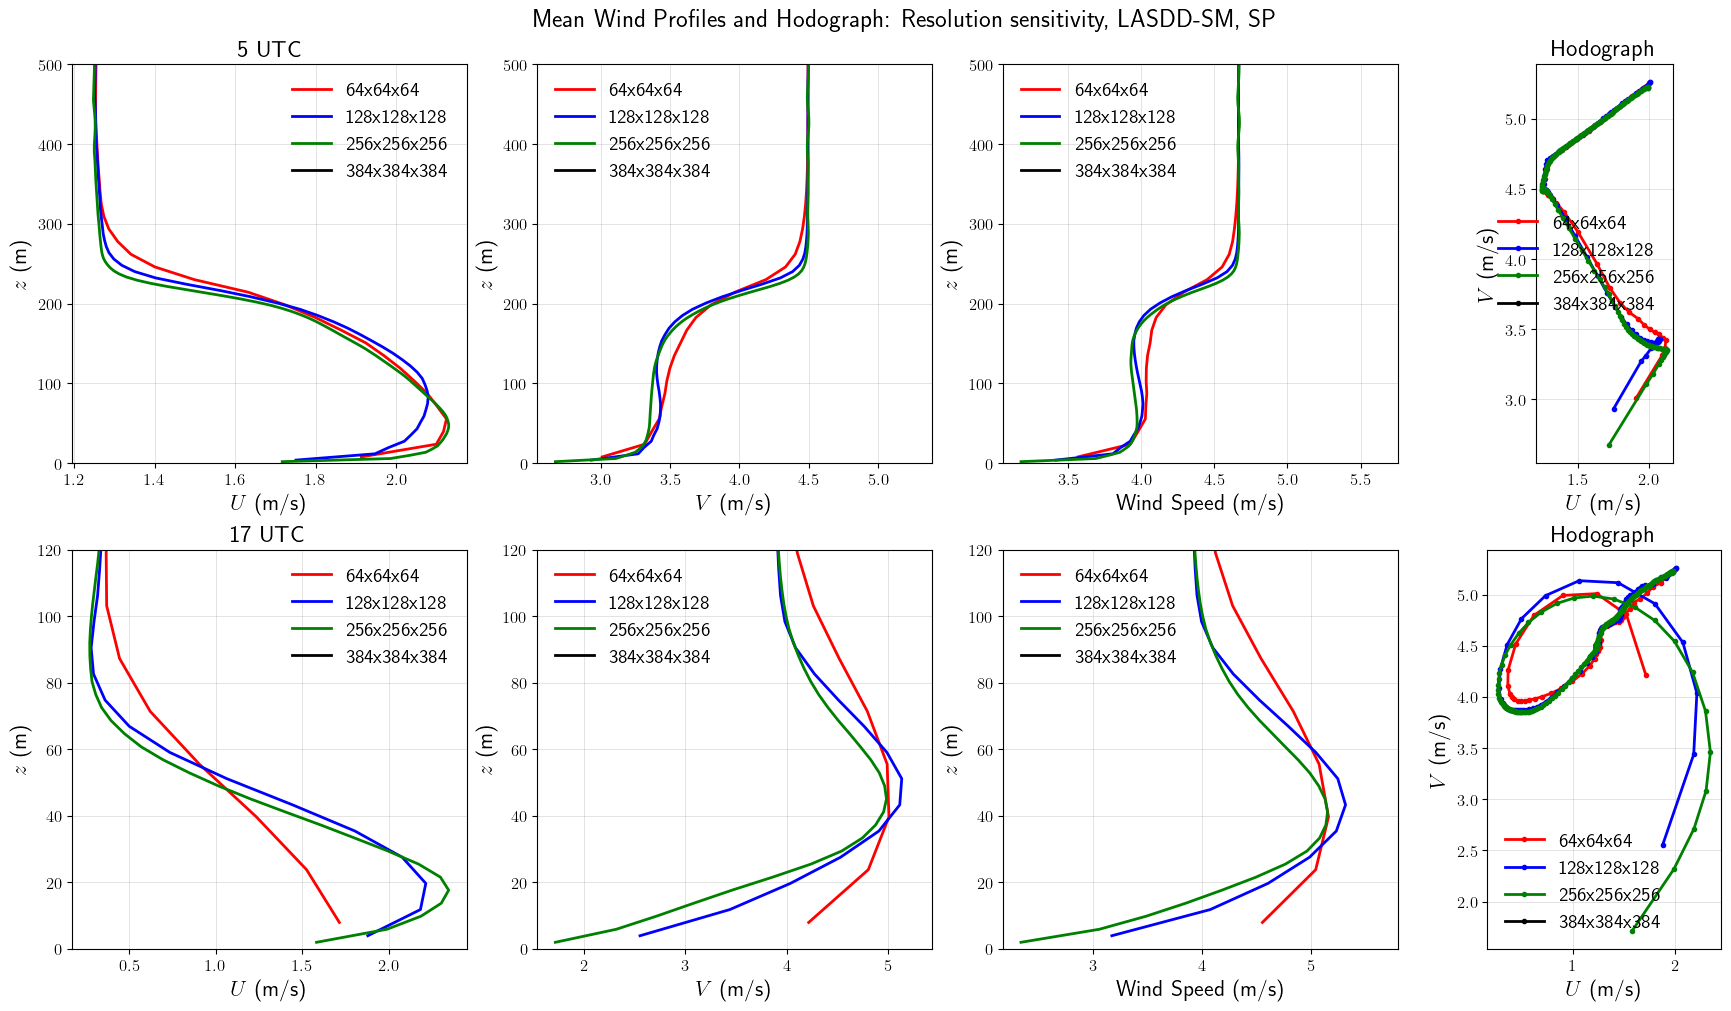

In [21]:
fig, axs = plt.subplots(2, 4, figsize=(18, 10), constrained_layout=True)

for row, (tag,
          U1,V1,S1,z1, U2,V2,S2,z2,
          U3,V3,S3,z3, U4,V4,S4,z4) in enumerate([
    ('5 UTC',
     U1_a,V1_a,S1_a,z_1, U2_a,V2_a,S2_a,z_2,
     U3_a,V3_a,S3_a,z_3, U4_a,V4_a,S4_a,z_4),
    ('17 UTC',
     U1_b,V1_b,S1_b,z_1, U2_b,V2_b,S2_b,z_2,
     U3_b,V3_b,S3_b,z_3, U4_b,V4_b,S4_b,z_4),
]):
    z_max = z_maxs[row]
    for lbl, U, V, S, zz in [
        ('64x64x64',   U1,V1,S1,z1),
        ('128x128x128',U2,V2,S2,z2),
        ('256x256x256',U3,V3,S3,z3),
        ('384x384x384',U4,V4,S4,z4),
    ]:
        prf(axs[row,0], U, zz, r'$U$ (m/s)',        lbl)
        prf(axs[row,1], V, zz, r'$V$ (m/s)',        lbl)
        prf(axs[row,2], S, zz, r'Wind Speed (m/s)', lbl)
        s = run_styles[lbl]
        axs[row,3].plot(U, V, color=s['color'], linestyle='-',
                        marker='o', linewidth=2, markersize=3, label=lbl)

    axs[row,3].set_xlabel(r'$U$ (m/s)')
    axs[row,3].set_ylabel(r'$V$ (m/s)')
    axs[row,3].set_title('Hodograph')
    axs[row,3].set_aspect('equal')
    for ax in axs[row]:
        ax.grid(); ax.legend(frameon=False)
    axs[row,0].set_title(tag)

fig.suptitle(
    f'Mean Wind Profiles and Hodograph: Resolution sensitivity, {_sgs_label[optSGS]}, SP',
    fontsize=18
)
plt.show()

## Mean Potential Temperature and Temperature Variance

Horizontally averaged potential-temperature profile and resolved temperature variance. Top: 5 UTC; bottom: 17 UTC.

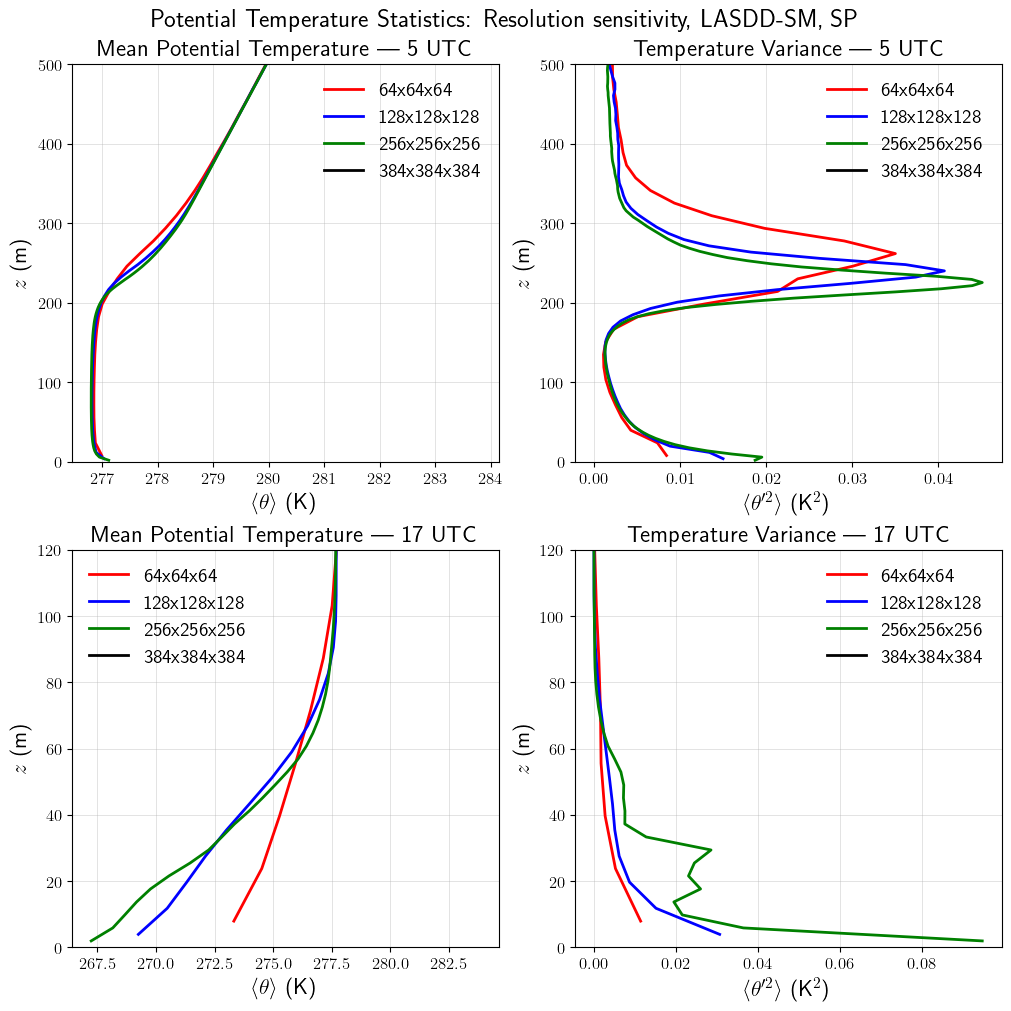

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)

for row, (tag, TH1,z1,v1, TH2_,z2,v2, TH3,z3,v3, TH4,z4,v4) in enumerate([
    ('5 UTC',
     TH1_a,z_1,TH2_1a, TH2_a,z_2,TH2_2a, TH3_a,z_3,TH2_3a, TH4_a,z_4,TH2_4a),
    ('17 UTC',
     TH1_b,z_1,TH2_1b, TH2_b,z_2,TH2_2b, TH3_b,z_3,TH2_3b, TH4_b,z_4,TH2_4b),
]):
    z_max = z_maxs[row]
    for lbl, TH, zz, TH2v in [
        ('64x64x64',   TH1,z1,v1),
        ('128x128x128',TH2_,z2,v2),
        ('256x256x256',TH3,z3,v3),
        ('384x384x384',TH4,z4,v4),
    ]:
        s = run_styles[lbl]
        axs[row,0].plot(TH,   zz, color=s['color'], linestyle=s['linestyle'],
                        linewidth=2, label=lbl)
        axs[row,1].plot(TH2v, zz, color=s['color'], linestyle=s['linestyle'],
                        linewidth=2, label=lbl)

    axs[row,0].set_xlabel(r'$\langle\theta\rangle$ (K)')
    axs[row,0].set_ylabel(r'$z$ (m)')
    axs[row,0].set_ylim(0, z_max)
    axs[row,0].set_title(f'Mean Potential Temperature — {tag}')
    axs[row,1].set_xlabel(r"$\langle\theta'^2\rangle$ (K$^2$)")
    axs[row,1].set_ylabel(r'$z$ (m)')
    axs[row,1].set_ylim(0, z_max)
    axs[row,1].set_title(f'Temperature Variance — {tag}')
    for ax in axs[row]:
        ax.grid(); ax.legend(frameon=False)

fig.suptitle(
    f'Potential Temperature Statistics: Resolution sensitivity, {_sgs_label[optSGS]}, SP',
    fontsize=18
)
plt.show()

## Resolved Velocity Variances

Resolved variance profiles of $u$, $v$, and $w$. Top: 5 UTC; bottom: 17 UTC.

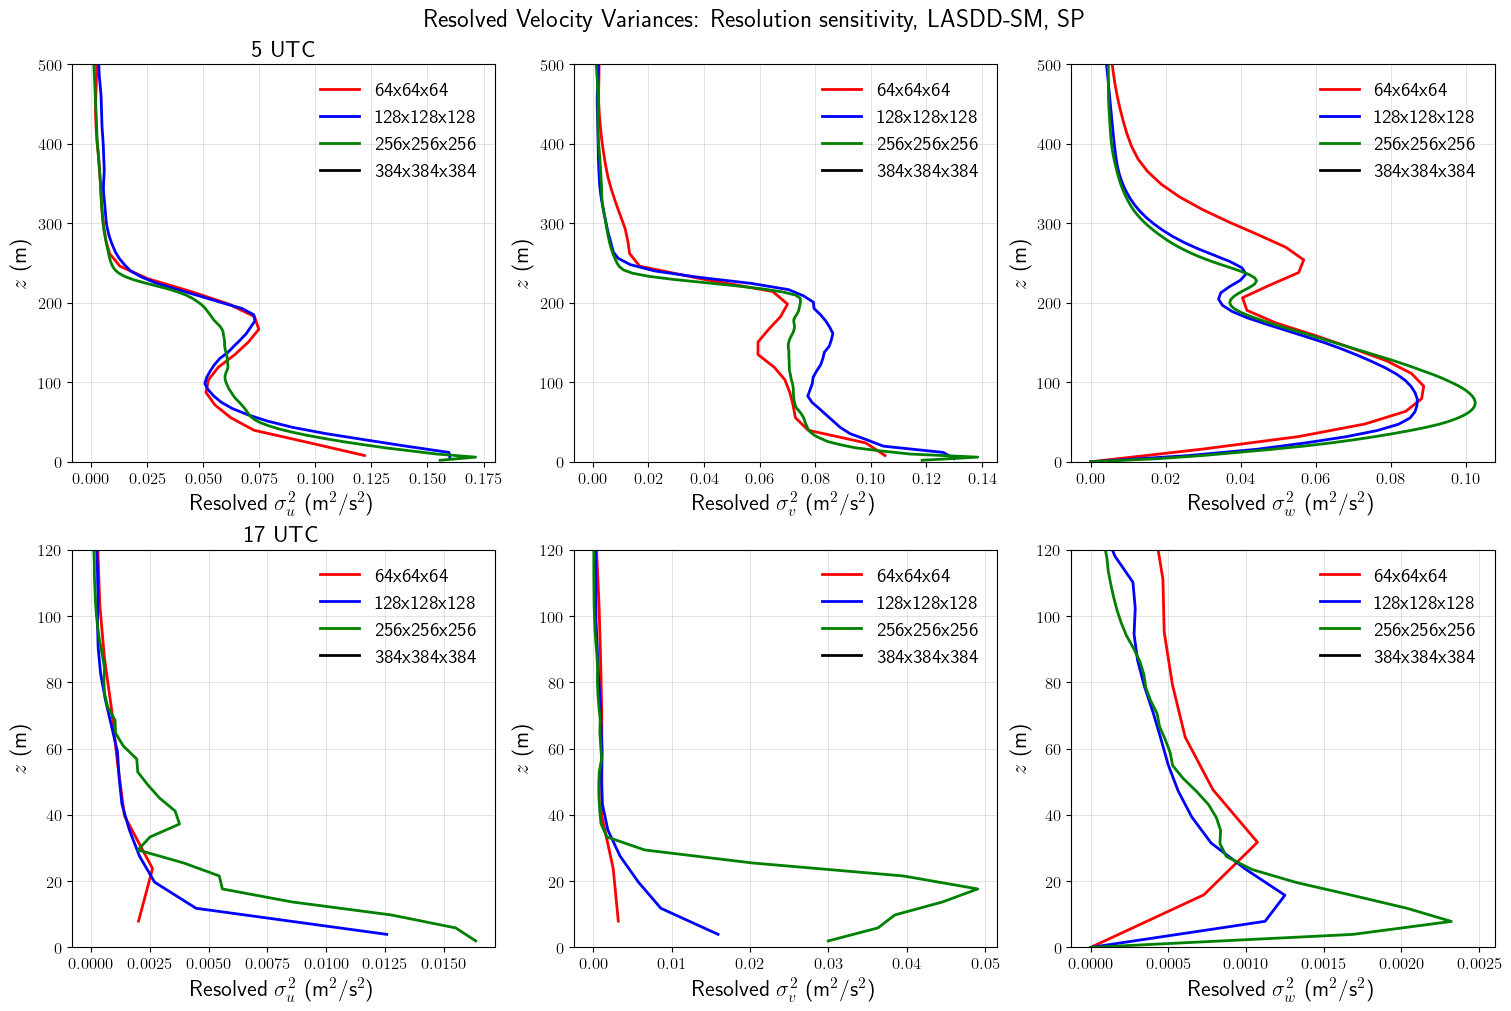

In [23]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)

for row, (tag,
          u21,v21,w21,z1,zw1,
          u22,v22,w22,z2,zw2,
          u23,v23,w23,z3,zw3,
          u24,v24,w24,z4,zw4) in enumerate([
    ('5 UTC',
     u2_1a,v2_1a,w2_1a,z_1,z_w1,
     u2_2a,v2_2a,w2_2a,z_2,z_w2,
     u2_3a,v2_3a,w2_3a,z_3,z_w3,
     u2_4a,v2_4a,w2_4a,z_4,z_w4),
    ('17 UTC',
     u2_1b,v2_1b,w2_1b,z_1,z_w1,
     u2_2b,v2_2b,w2_2b,z_2,z_w2,
     u2_3b,v2_3b,w2_3b,z_3,z_w3,
     u2_4b,v2_4b,w2_4b,z_4,z_w4),
]):
    z_max = z_maxs[row]
    for lbl, u2,v2,w2,zz,zzw in [
        ('64x64x64',   u21,v21,w21,z1,zw1),
        ('128x128x128',u22,v22,w22,z2,zw2),
        ('256x256x256',u23,v23,w23,z3,zw3),
        ('384x384x384',u24,v24,w24,z4,zw4),
    ]:
        prf(axs[row,0], u2, zz,  r'Resolved $\sigma_u^2$ (m$^2$/s$^2$)', lbl)
        prf(axs[row,1], v2, zz,  r'Resolved $\sigma_v^2$ (m$^2$/s$^2$)', lbl)
        prf(axs[row,2], w2, zzw, r'Resolved $\sigma_w^2$ (m$^2$/s$^2$)', lbl)

    for ax in axs[row]:
        ax.grid(); ax.legend(frameon=False)
    axs[row,0].set_title(tag)

fig.suptitle(
    f'Resolved Velocity Variances: Resolution sensitivity, {_sgs_label[optSGS]}, SP',
    fontsize=18
)
plt.show()

## Total Momentum and Heat Fluxes

Total (resolved + SGS) momentum and sensible heat fluxes. Top: 5 UTC; bottom: 17 UTC.

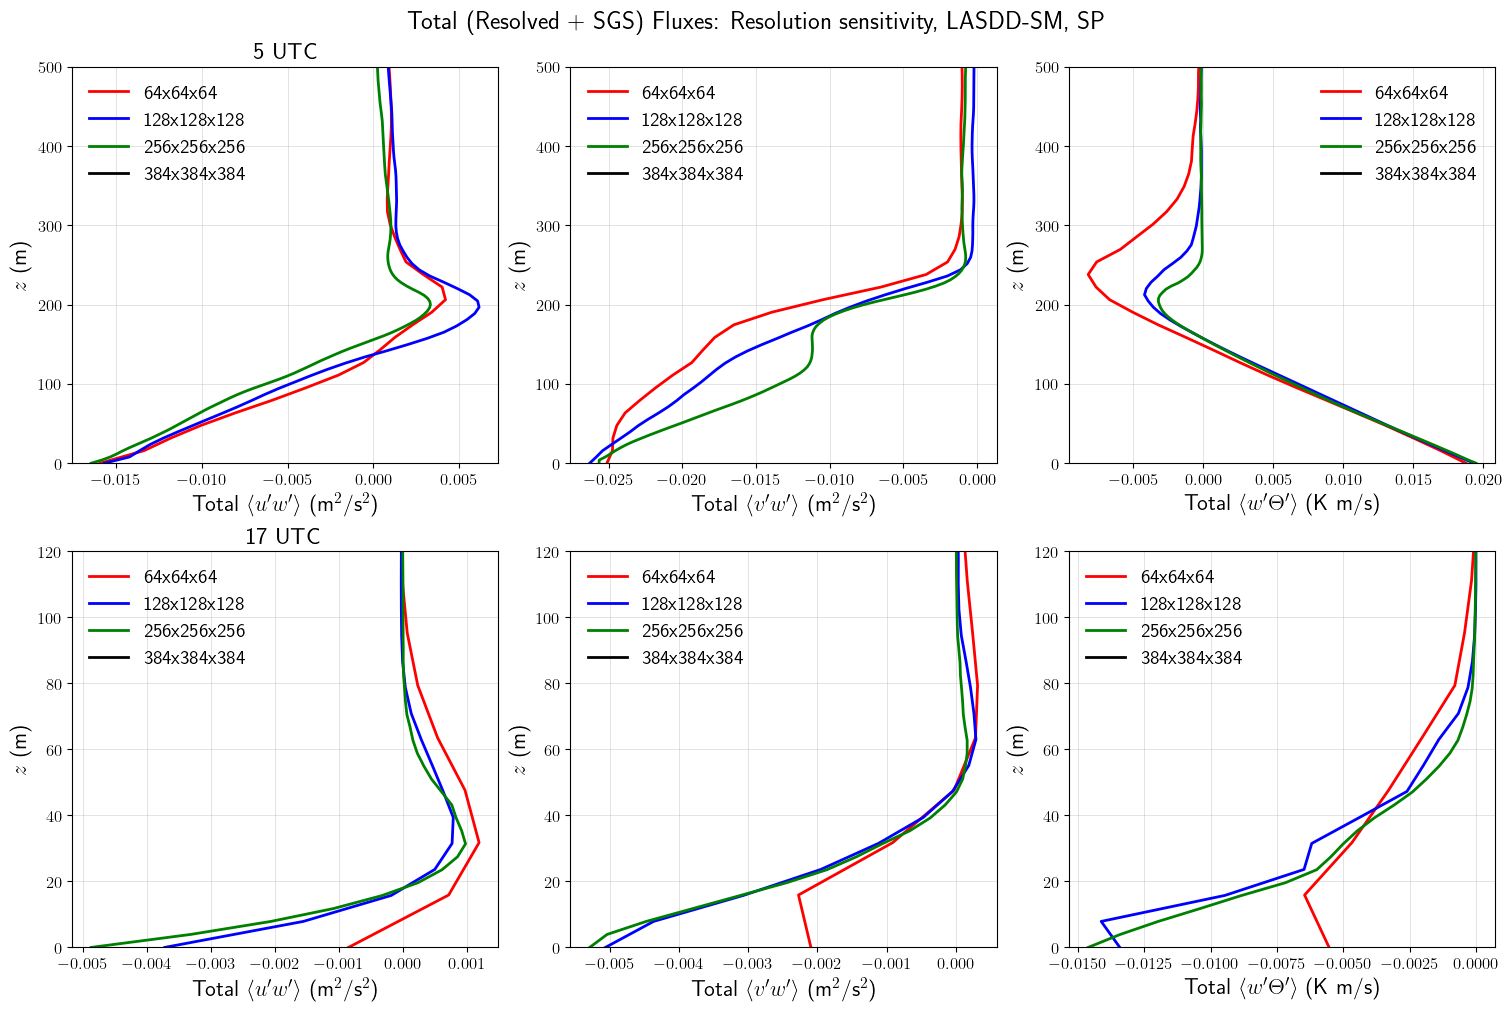

In [24]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)

for row, (tag,
          uw1,vw1,wt1,zw1,
          uw2,vw2,wt2,zw2,
          uw3,vw3,wt3,zw3,
          uw4,vw4,wt4,zw4) in enumerate([
    ('5 UTC',
     uw_tot_1a,vw_tot_1a,wT_tot_1a,z_w1,
     uw_tot_2a,vw_tot_2a,wT_tot_2a,z_w2,
     uw_tot_3a,vw_tot_3a,wT_tot_3a,z_w3,
     uw_tot_4a,vw_tot_4a,wT_tot_4a,z_w4),
    ('17 UTC',
     uw_tot_1b,vw_tot_1b,wT_tot_1b,z_w1,
     uw_tot_2b,vw_tot_2b,wT_tot_2b,z_w2,
     uw_tot_3b,vw_tot_3b,wT_tot_3b,z_w3,
     uw_tot_4b,vw_tot_4b,wT_tot_4b,z_w4),
]):
    z_max = z_maxs[row]
    for lbl, uw,vw,wt,zzw in [
        ('64x64x64',   uw1,vw1,wt1,zw1),
        ('128x128x128',uw2,vw2,wt2,zw2),
        ('256x256x256',uw3,vw3,wt3,zw3),
        ('384x384x384',uw4,vw4,wt4,zw4),
    ]:
        prf(axs[row,0], uw, zzw, r"Total $\langle u'w'\rangle$ (m$^2$/s$^2$)", lbl)
        prf(axs[row,1], vw, zzw, r"Total $\langle v'w'\rangle$ (m$^2$/s$^2$)", lbl)
        prf(axs[row,2], wt, zzw, r"Total $\langle w'\Theta'\rangle$ (K m/s)",  lbl)

    for ax in axs[row]:
        ax.grid(); ax.legend(frameon=False)
    axs[row,0].set_title(tag)

fig.suptitle(
    f'Total (Resolved + SGS) Fluxes: Resolution sensitivity, {_sgs_label[optSGS]}, SP',
    fontsize=18
)
plt.show()